✅ Libraries Successfully Loaded!
=== 1. DATASET OVERVIEW ===
Total Rows (Records): 681
Total Columns (Features): 12

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  681 non-null    int64  
 1   Survived     681 non-null    int64  
 2   Pclass       681 non-null    int64  
 3   Name         681 non-null    str    
 4   Sex          681 non-null    str    
 5   Age          534 non-null    float64
 6   SibSp        681 non-null    int64  
 7   Parch        681 non-null    int64  
 8   Ticket       681 non-null    object 
 9   Fare         681 non-null    float64
 10  Cabin        137 non-null    str    
 11  Embarked     680 non-null    str    
dtypes: float64(2), int64(5), object(1), str(4)
memory usage: 64.0+ KB
None

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


=== 2. DATA QUALITY CHECK ===
Total Duplicate Rows: 0

--- Missing Values Breakdown ---


,Missing Count,Missing Percentage (%)
Age,147,21.585903
Cabin,544,79.882526
Embarked,1,0.146843


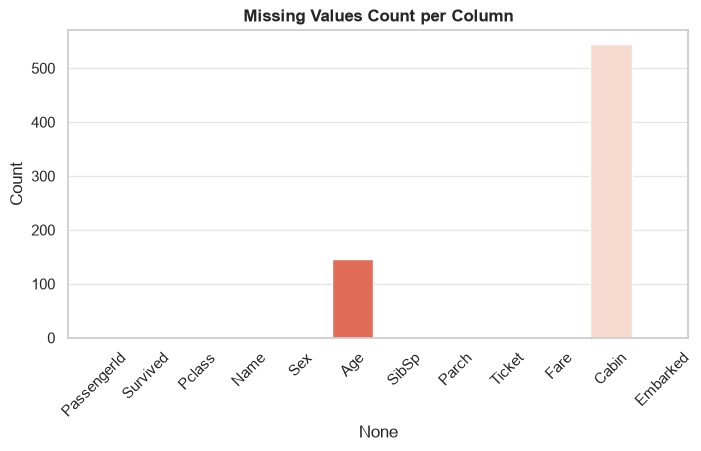

=== 3. SURVIVAL ANALYSIS (Target Variable) ===


,Count,Percentage (%)
Died (0),442,64.904552
Survived (1),239,35.095448


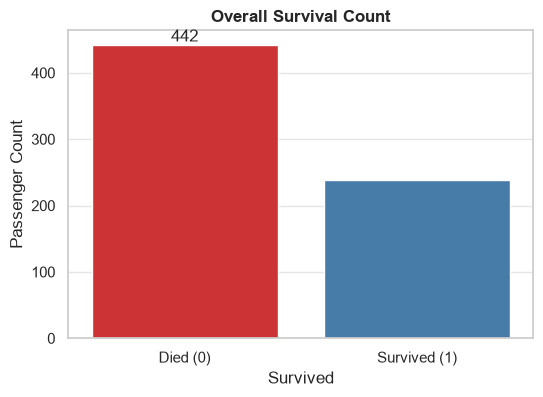

=== 4. GENDER ANALYSIS (Sex Column) ===


,Gender,Total Passengers,Survived Count,Survival Rate (%)
0,female,206,159,77.184466
1,male,475,80,16.842105


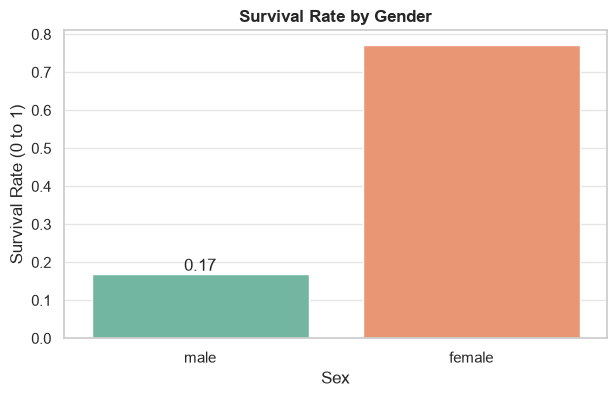

=== 5. PASSENGER CLASS ANALYSIS (Pclass Column) ===


,Pclass,Total Passengers,Survived Count,Survival Rate (%)
0,1,147,83,56.462585
1,2,140,62,44.285714
2,3,394,94,23.857868


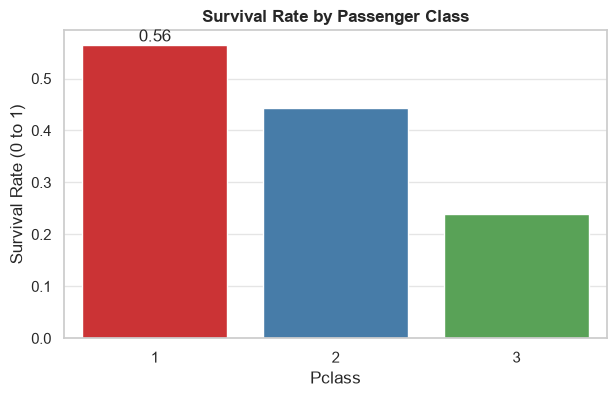

=== 6. AGE COLUMN ANALYSIS & IMPUTATION ===
Age Statistics Before Imputation:


count    534.000000
mean      30.949906
std       13.740835
min        0.420000
25%       22.000000
50%       29.000000
75%       39.000000
max       80.000000
Name: Age, dtype: float64

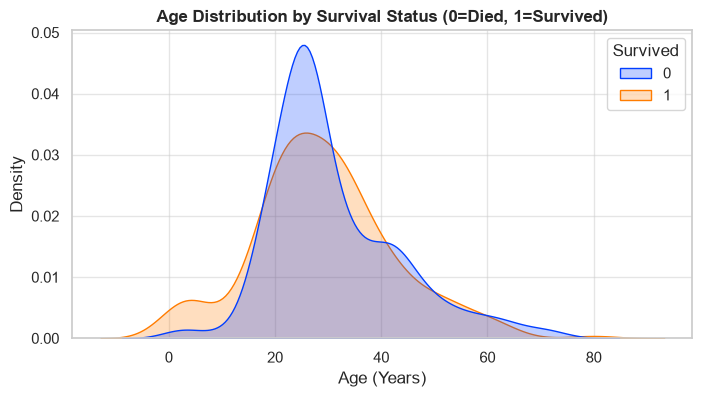

=== 7. TICKET FARE ANALYSIS (Fare Column) ===
Total Fare Collected (Total Revenue): $15,849.67
Average Fare per Ticket: $23.27
Minimum Fare: $0.00
Maximum Fare: $512.33



,Pclass,mean,median,min,max
0,1,64.139286,49.5042,0.0,512.3292
1,2,17.509702,13.0000,0.0,73.5000
2,3,10.075739,7.8958,0.0,69.5500


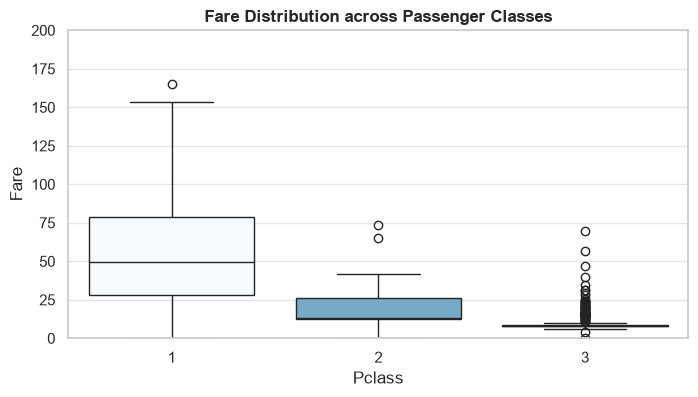

=== 8. EMBARKATION PORT ANALYSIS (Embarked Column) ===


,Embarked Port,Total Passengers,Survived Count,Survival Rate (%)
0,C,120,59,49.166667
1,Q,66,27,40.909091
2,S,495,153,30.909091


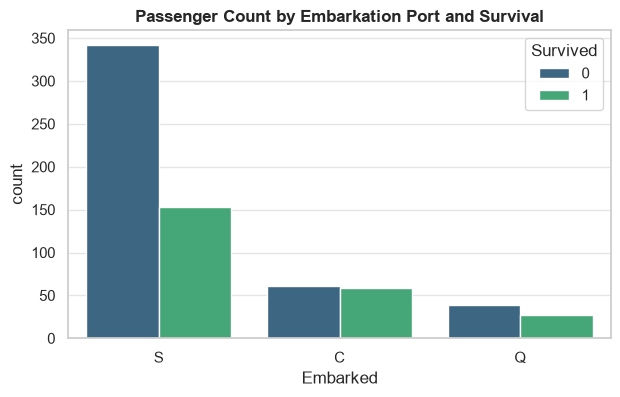

=== 9. FEATURE ENGINEERING & FINAL DATASET EXPORT ===
✅ Cleaned Dataset saved as 'cleaned_titanic.csv'


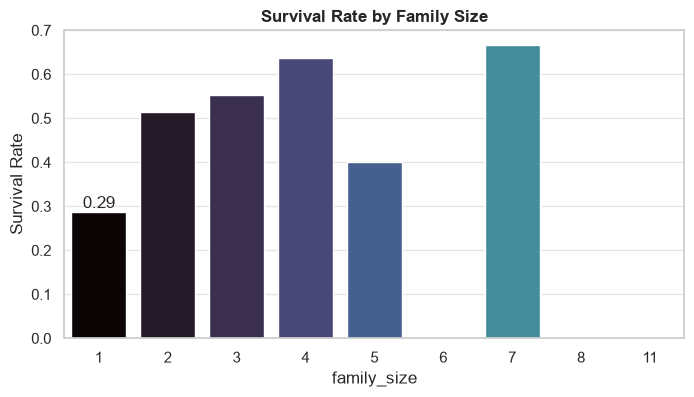

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
print("✅ Libraries Successfully Loaded!")
df = pd.read_excel('Titanic-Dataset.xlsx')

print("=== 1. DATASET OVERVIEW ===")
print(f"Total Rows (Records): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

print("--- Data Types & Non-Null Counts ---")
print(df.info())

print("\n--- First 5 Rows ---")
display(df.head())
print("=== 2. DATA QUALITY CHECK ===")
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}\n")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("--- Missing Values Breakdown ---")
display(missing_df[missing_df['Missing Count'] > 0])
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing Count'], palette='Reds_r', hue=missing_df.index, legend=False)
plt.title('Missing Values Count per Column', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
print("=== 3. SURVIVAL ANALYSIS (Target Variable) ===")

survived_counts = df['Survived'].value_counts()
survived_pct = df['Survived'].value_counts(normalize=True) * 100

surv_summary = pd.DataFrame({'Count': survived_counts, 'Percentage (%)': survived_pct})
surv_summary.index = ['Died (0)', 'Survived (1)']
display(surv_summary)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Survived', palette='Set1', hue='Survived', legend=False)
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'])
plt.title('Overall Survival Count', fontweight='bold')
plt.ylabel('Passenger Count')
ax.bar_label(ax.containers[0])
plt.show()

print("=== 4. GENDER ANALYSIS (Sex Column) ===")

gender_summary = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
gender_summary.columns = ['Gender', 'Total Passengers', 'Survived Count', 'Survival Rate (%)']
gender_summary['Survival Rate (%)'] = gender_summary['Survival Rate (%)'] * 100
display(gender_summary)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=df, x='Sex', y='Survived', palette='Set2', hue='Sex', legend=False, errorbar=None)
plt.title('Survival Rate by Gender', fontweight='bold')
plt.ylabel('Survival Rate (0 to 1)')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.show()
print("=== 5. PASSENGER CLASS ANALYSIS (Pclass Column) ===")

class_summary = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
class_summary.columns = ['Pclass', 'Total Passengers', 'Survived Count', 'Survival Rate (%)']
class_summary['Survival Rate (%)'] = class_summary['Survival Rate (%)'] * 100
display(class_summary)
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=df, x='Pclass', y='Survived', palette='Set1', hue='Pclass', legend=False, errorbar=None)
plt.title('Survival Rate by Passenger Class', fontweight='bold')
plt.ylabel('Survival Rate (0 to 1)')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.show()
print("=== 6. AGE COLUMN ANALYSIS & IMPUTATION ===")

print(f"Age Statistics Before Imputation:")
display(df['Age'].describe())
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, palette='bright', common_norm=False)
plt.title('Age Distribution by Survival Status (0=Died, 1=Survived)', fontweight='bold')
plt.xlabel('Age (Years)')
plt.show()
print("=== 7. TICKET FARE ANALYSIS (Fare Column) ===")

print(f"Total Fare Collected (Total Revenue): ${df['Fare'].sum():,.2f}")
print(f"Average Fare per Ticket: ${df['Fare'].mean():.2f}")
print(f"Minimum Fare: ${df['Fare'].min():.2f}")
print(f"Maximum Fare: ${df['Fare'].max():.2f}\n")
fare_by_class = df.groupby('Pclass')['Fare'].agg(['mean', 'median', 'min', 'max']).reset_index()
display(fare_by_class)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Blues', hue='Pclass', legend=False)
plt.title('Fare Distribution across Passenger Classes', fontweight='bold')
plt.ylim(0, 200) # Outliers scale adjustment
plt.show()
print("=== 8. EMBARKATION PORT ANALYSIS (Embarked Column) ===")
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

emb_summary = df.groupby('Embarked')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
emb_summary.columns = ['Embarked Port', 'Total Passengers', 'Survived Count', 'Survival Rate (%)']
emb_summary['Survival Rate (%)'] = emb_summary['Survival Rate (%)'] * 100
display(emb_summary)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Embarked', hue='Survived', palette='viridis')
plt.title('Passenger Count by Embarkation Port and Survival', fontweight='bold')
plt.show()
print("=== 9. FEATURE ENGINEERING & FINAL DATASET EXPORT ===")
df['Cabin_Known'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)
df.columns = [c.lower() for c in df.columns]
df.to_csv('cleaned_titanic.csv', index=False)
print("✅ Cleaned Dataset saved as 'cleaned_titanic.csv'")
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df, x='family_size', y='survived', palette='mako', hue='family_size', legend=False, errorbar=None)
plt.title('Survival Rate by Family Size', fontweight='bold')
plt.ylabel('Survival Rate')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.show()